# COCA Gated CT Preprocessing — Corrected XML Matching Pipeline

This notebook replaces the faulty logic in the earlier preprocessing scripts.

## What was wrong

The old code searched the XML for `UID` values and tried to match them to DICOM `SOPInstanceUID`.  
That is wrong for the COCA gated XML files.

The actual XML structure is plist-style:

```text
Images
├── ImageIndex
└── ROIs
    └── Point_px
```

The correct matching is:

```text
patient folder ID ↔ XML filename
sorted DICOM slice index ↔ XML ImageIndex
Point_px polygon ↔ binary mask on that slice
```

## What this notebook does

1. Reads nested DICOM folders recursively.
2. Sorts slices by z-position.
3. Converts raw DICOM values to HU.
4. Windows HU to `[0, 1]`.
5. Parses XML with `plistlib`.
6. Extracts valid polygon ROIs from `Point_px`.
7. Uses XML `ImageIndex` to assign masks to slices.
8. Automatically checks whether indices are 0-based or 1-based using z-coordinates.
9. Builds 2.5D stacks:
   - `X[k] = [slice k-1, slice k, slice k+1]`
   - `Y[k] = mask for slice k`
10. Saves:
    ```text
    processed_data/
    ├── images/case_001.npy
    ├── masks/case_001.npy
    ├── processing_manifest.csv
    └── xml_roi_audit.csv
    ```

**Do not train a model until the visual mask overlays pass.**

In [1]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any
import re
import math
import traceback
import plistlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom
import cv2

print("Imports successful.")

Imports successful.


## 1. Config

Holds path, vars, and options to directories, HU convertion, sorting slices

In [2]:
@dataclass
class PreprocessConfig:
    GATED_ROOT: Path = Path(r"Gated_release_final")
    ROOT_SLICES: Path = GATED_ROOT / "patient"
    ROOT_LABELS: Path = GATED_ROOT / "calcium_xml"
    OUTPUT_ROOT: Path = GATED_ROOT / "processed_data"
    OUTPUT_IMGS: Path = OUTPUT_ROOT / "images"
    OUTPUT_MASKS: Path = OUTPUT_ROOT / "masks"

    TARGET_SIZE: Tuple[int, int] = (512, 512)
    hu_low: float = -200.0
    hu_high: float = 1000.0

    # Index mapping mode:
    # auto -> compare z-coordinate consistency between offset 0 and offset -1.
    index_mode: str = "auto"  # auto, zero_based, one_based

    # 2.5D boundaries:
    boundary_mode: str = "replicate"  # replicate or zero

    overwrite_existing: bool = True
    save_float_dtype: Any = np.float32
    mask_dtype: Any = np.uint8

    # Empty placeholder ROI records must be skipped.
    require_positive_area: bool = True
    require_min_polygon_points: int = 3

    # Use small integer first for debugging; set to None for all cases.
    max_cases: Optional[int] = None

cfg = PreprocessConfig()
TARGET_SIZE = cfg.TARGET_SIZE
hu_low = cfg.hu_low
hu_high = cfg.hu_high

index_mode = cfg.index_mode
boundary_mode = cfg.boundary_mode

ROOT_SLICES = cfg.ROOT_SLICES
ROOT_LABELS = cfg.ROOT_LABELS
OUTPUT_ROOT = cfg.OUTPUT_ROOT
OUTPUT_IMGS = cfg.OUTPUT_IMGS
OUTPUT_MASKS = cfg.OUTPUT_MASKS

print("DICOM root:", ROOT_SLICES)
print("XML root:", ROOT_LABELS)
print("Output imgs:", OUTPUT_IMGS)
print("Output masks:", OUTPUT_MASKS)

DICOM root: Gated_release_final\patient
XML root: Gated_release_final\calcium_xml
Output imgs: Gated_release_final\processed_data\images
Output masks: Gated_release_final\processed_data\masks


In [3]:
def validate_paths(cfg: PreprocessConfig) -> None:
    assert ROOT_SLICES.exists(), f"DICOM root not found: {cfg.ROOT_SLICES}"
    assert ROOT_LABELS.exists(), f"XML root not found: {cfg.ROOT_LABELS}"

    OUTPUT_IMGS.mkdir(parents=True, exist_ok=True)
    OUTPUT_MASKS.mkdir(parents=True, exist_ok=True)

    print("Path validation passed.")
    print("Patient folders:", len([p for p in ROOT_SLICES.iterdir() if p.is_dir()]))
    print("XML files:", len(list(cfg.ROOT_LABELS.glob('*.xml'))))

# Run after setting GATED_ROOT:
validate_paths(cfg)

Path validation passed.
Patient folders: 787
XML files: 451


## 2. Utilities

In [ ]:
def numeric_sort_key(name: str):
    return int(name) if str(name).isdigit() else str(name)

def case_filename(patient_id: str) -> str:
    if str(patient_id).isdigit():
        return f"{int(patient_id):03d}"
    return f"{patient_id}"

def parse_tuple_string(s: str, expected_len: int = 2) -> Tuple[float, ...]:
    nums = re.findall(r"[-+]?(?:\d*\.\d+|\d+)", s)
    values = tuple(float(x) for x in nums)
    if len(values) < expected_len:
        raise ValueError(f"Could not parse {expected_len} values from: {s}")
    return values[:expected_len]

def point_px_to_int_xy(point_string: str) -> List[int]:
    x, y = parse_tuple_string(point_string, expected_len=2)
    return [int(round(x)), int(round(y))]

def normalize_hu(hu: np.ndarray, low: float, high: float) -> np.ndarray:
    hu = np.clip(hu, low, high)
    return ((hu - low) / (high - low)).astype(np.float32)

def find_dicom_files_recursive(patient_dir: Path) -> List[Path]:
    return sorted(patient_dir.rglob("*.dcm"))

## 3. DICOM loading and sorting
### 3.1. Convert px to Hounsfield Units
### 3.2. Clip it to [0, 1]
### 3.3. Sort slices by case and name

In [5]:
def read_dicom_slice(path: Path, cfg: PreprocessConfig) -> Optional[Dict[str, Any]]:
    try:
        ds = pydicom.dcmread(str(path), force=True)
        if "PixelData" not in ds or not hasattr(ds, "ImagePositionPatient"):
            return None

        # Convert to HU
        raw = ds.pixel_array.astype(np.float32)
        slope = float(getattr(ds, "RescaleSlope", 1.0))
        intercept = float(getattr(ds, "RescaleIntercept", 0.0))
        hu = raw * slope + intercept
        image = normalize_hu(hu, hu_low, hu_high)

        if image.shape != TARGET_SIZE:
            image = cv2.resize(
                image,
                (cfg.TARGET_SIZE[1], TARGET_SIZE[0]),
                interpolation=cv2.INTER_LINEAR
            ).astype(np.float32)

        return {
            "path": str(path),
            "image": image,
            "z": float(ds.ImagePositionPatient[2]),
            "instance_number": int(getattr(ds, "InstanceNumber", -1)),
            "sop_uid": str(getattr(ds, "SOPInstanceUID", "")),
            "pixel_spacing": tuple(float(v) for v in getattr(ds, "PixelSpacing", [np.nan, np.nan])),
            "slice_thickness": float(getattr(ds, "SliceThickness", np.nan)),
        }
    except Exception as e:
        print(f"Warning: failed to read DICOM {path}: {e}")
        return None

def load_sorted_dicom_volume(patient_dir: Path, cfg: PreprocessConfig) -> List[Dict[str, Any]]:
    dcm_files = find_dicom_files_recursive(patient_dir)
    slices = [read_dicom_slice(p, cfg) for p in dcm_files]
    slices = [s for s in slices if s is not None]

    if not slices:
        raise RuntimeError(f"No readable DICOM slices found in {patient_dir}")

    return sorted(slices, key=lambda s: s["z"])

## 4. XML parser

It uses `plistlib` and returns:

```python
labels[ImageIndex] = [polygon1, polygon2, ...]
```

Targeting `ImageIndex`, `ROIs`, and `Point_px`; only save to labels if number(`Point_px`) >= 3

In [6]:
def parse_coca_calcium_xml(
    xml_path: Path,
    cfg: PreprocessConfig
) -> Tuple[Dict[int, List[np.ndarray]], pd.DataFrame]:
    with open(xml_path, "rb") as f:
        data = plistlib.load(f)

    labels: Dict[int, List[np.ndarray]] = {}
    audit_rows = []

    for image_entry in data.get("Images", []):
        image_index = int(image_entry.get("ImageIndex"))
        polygons = []

        for roi in image_entry.get("ROIs", []):
            area = float(roi.get("Area", 0.0))
            point_px = roi.get("Point_px", [])
            point_mm = roi.get("Point_mm", [])
            number_of_points = int(roi.get("NumberOfPoints", 0))
            index_in_image = int(roi.get("IndexInImage", -1))
            roi_name = str(roi.get("Name", ""))

            z_from_point_mm = np.nan
            if point_mm:
                try:
                    _, _, z_from_point_mm = parse_tuple_string(point_mm[0], expected_len=3)
                except Exception:
                    z_from_point_mm = np.nan

            polygon = None
            polygon_valid = False

            if point_px:
                try:
                    polygon = np.array(
                        [point_px_to_int_xy(p) for p in point_px],
                        dtype=np.int32
                    )
                    polygon_valid = len(polygon) >= cfg.require_min_polygon_points
                except Exception:
                    polygon = None
                    polygon_valid = False

            keep_roi = polygon_valid
            if cfg.require_positive_area:
                keep_roi = keep_roi and (area > 0.0)

            if keep_roi and polygon is not None:
                polygons.append(polygon)

            audit_rows.append({
                "xml_file": xml_path.name,
                "image_index": image_index,
                "index_in_image": index_in_image,
                "roi_name": roi_name,
                "area": area,
                "number_of_points_reported": number_of_points,
                "number_of_point_px": len(point_px),
                "polygon_valid": bool(polygon_valid),
                "keep_roi": bool(keep_roi),
                "z_from_point_mm": z_from_point_mm,
            })

        if polygons:
            labels[image_index] = polygons

    return labels, pd.DataFrame(audit_rows)

In [7]:
def inspect_one_xml(xml_path: Path, cfg: PreprocessConfig):
    labels, roi_audit = parse_coca_calcium_xml(xml_path, cfg)
    print("XML:", xml_path)
    print("Retained annotated image indices:", sorted(labels.keys())[:60])
    print("Annotated slice count:", len(labels))
    print("ROI records:", len(roi_audit))
    print("Retained ROI polygons:", int(roi_audit["keep_roi"].sum()))
    print("Skipped ROI records:", int((~roi_audit["keep_roi"]).sum()))
    return labels, roi_audit

# Example:
labels_1, roi_audit_1 = inspect_one_xml(cfg.ROOT_LABELS / "1.xml", cfg)
roi_audit_1.head(20)

XML: Gated_release_final\calcium_xml\1.xml
Retained annotated image indices: [12, 19, 26, 27, 28, 39, 40, 41]
Annotated slice count: 8
ROI records: 20
Retained ROI polygons: 16
Skipped ROI records: 4


,xml_file,image_index,index_in_image,roi_name,area,number_of_points_reported,number_of_point_px,polygon_valid,keep_roi,z_from_point_mm
0,1.xml,12,0,Right Coronary Artery,0.026378,20,20,True,True,-214.75
1,1.xml,19,0,Right Coronary Artery,0.014655,14,14,True,True,-193.75
2,1.xml,26,0,Right Coronary Artery,0.005862,8,8,True,True,-172.75
3,1.xml,26,1,Right Coronary Artery,0.000000,0,0,False,False,NaN
4,1.xml,26,2,Right Coronary Artery,0.000000,0,0,False,False,NaN
5,1.xml,27,0,Right Coronary Artery,0.093789,36,36,True,True,-169.75
6,1.xml,27,1,Right Coronary Artery,0.010258,12,12,True,True,-169.75
7,1.xml,27,2,Right Coronary Artery,0.000000,0,0,False,False,NaN
8,1.xml,27,3,Right Coronary Artery,0.000000,0,0,False,False,NaN
9,1.xml,28,0,Right Coronary Artery,0.073273,34,34,True,True,-166.75


## 5. Infer whether XML `ImageIndex` is zero-based or one-based

The notebook compares XML z coordinates to DICOM slice z coordinates.

- Offset `0`: `slice_index = ImageIndex`
- Offset `-1`: `slice_index = ImageIndex - 1`

Whichever produces lower median z-error is selected.

In [8]:
def extract_reference_z_per_image_index(roi_audit: pd.DataFrame) -> Dict[int, float]:
    if roi_audit.empty:
        return {}

    use_df = roi_audit[
        (roi_audit["keep_roi"] == True) &
        (~roi_audit["z_from_point_mm"].isna())
    ].copy()

    if use_df.empty:
        return {}

    return use_df.groupby("image_index")["z_from_point_mm"].median().to_dict()

def evaluate_index_offset(
    slices: List[Dict[str, Any]],
    xml_z_by_index: Dict[int, float],
    offset: int
) -> Dict[str, Any]:
    errors = []
    pairs = []

    for image_index, xml_z in xml_z_by_index.items():
        slice_index = int(image_index + offset)
        if 0 <= slice_index < len(slices):
            dicom_z = float(slices[slice_index]["z"])
            abs_error = abs(dicom_z - float(xml_z))
            errors.append(abs_error)
            pairs.append({
                "xml_image_index": int(image_index),
                "slice_index_used": int(slice_index),
                "xml_z": float(xml_z),
                "dicom_z": dicom_z,
                "abs_z_error": abs_error,
                "offset": int(offset),
            })

    if not errors:
        return {
            "offset": offset,
            "n_pairs": 0,
            "median_abs_z_error": np.inf,
            "mean_abs_z_error": np.inf,
            "pairs": pd.DataFrame()
        }

    return {
        "offset": offset,
        "n_pairs": len(errors),
        "median_abs_z_error": float(np.median(errors)),
        "mean_abs_z_error": float(np.mean(errors)),
        "pairs": pd.DataFrame(pairs),
    }

def infer_image_index_offset(
    slices: List[Dict[str, Any]],
    roi_audit: pd.DataFrame,
    cfg: PreprocessConfig
) -> Tuple[int, Dict[str, Any]]:
    if index_mode == "zero_based":
        return 0, {"decision": "forced_zero_based", "chosen_offset": 0}

    if index_mode == "one_based":
        return -1, {"decision": "forced_one_based", "chosen_offset": -1}

    if index_mode != "auto":
        raise ValueError(f"Unknown index_mode: {cfg.index_mode}")

    xml_z_by_index = extract_reference_z_per_image_index(roi_audit)
    result_0 = evaluate_index_offset(slices, xml_z_by_index, offset=0)
    result_m1 = evaluate_index_offset(slices, xml_z_by_index, offset=-1)

    if result_0["median_abs_z_error"] <= result_m1["median_abs_z_error"]:
        chosen_offset = 0
        decision = "auto_chose_zero_based"
    else:
        chosen_offset = -1
        decision = "auto_chose_one_based"

    diagnostics = {
        "decision": decision,
        "chosen_offset": chosen_offset,
        "offset_0_n_pairs": result_0["n_pairs"],
        "offset_0_median_abs_z_error": result_0["median_abs_z_error"],
        "offset_0_mean_abs_z_error": result_0["mean_abs_z_error"],
        "offset_minus1_n_pairs": result_m1["n_pairs"],
        "offset_minus1_median_abs_z_error": result_m1["median_abs_z_error"],
        "offset_minus1_mean_abs_z_error": result_m1["mean_abs_z_error"],
        "pairs_offset_0": result_0["pairs"],
        "pairs_offset_minus1": result_m1["pairs"],
    }

    return chosen_offset, diagnostics

## 6. Build masks and 2.5D stacks

In [ ]:
def build_masks_for_case(
    n_slices: int,
    labels: Dict[int, List[np.ndarray]],
    offset: int,
    cfg: PreprocessConfig
) -> Tuple[np.ndarray, pd.DataFrame]:
    H, W = TARGET_SIZE
    masks = np.zeros((n_slices, 1, H, W), dtype=cfg.mask_dtype)

    assignment_rows = []

    for xml_image_index, polygons in labels.items():
        slice_index = int(xml_image_index + offset)
        assigned = 0 <= slice_index < n_slices

        if assigned:
            cv2.fillPoly(masks[slice_index, 0], polygons, 1)

        assignment_rows.append({
            "xml_image_index": int(xml_image_index),
            "slice_index_used": int(slice_index),
            "assigned_in_bounds": bool(assigned),
            "num_polygons": len(polygons),
        })

    return masks, pd.DataFrame(assignment_rows)

def get_context_slice(images: np.ndarray, index: int, cfg: PreprocessConfig) -> np.ndarray:
    D, H, W = images.shape

    if 0 <= index < D:
        return images[index]

    if boundary_mode == "replicate":
        return images[0] if index < 0 else images[D - 1]

    if boundary_mode == "zero":
        return np.zeros((H, W), dtype=images.dtype)

    raise ValueError(f"Unknown boundary_mode: {cfg.boundary_mode}")

def build_samples(
    images: np.ndarray,
    masks: np.ndarray,
    cfg: PreprocessConfig
) -> Tuple[np.ndarray, np.ndarray]:
    D, H, W = images.shape
    X = []

    for k in range(D):
        stack = np.stack([
            get_context_slice(images, k - 1, cfg),
            get_context_slice(images, k, cfg),
            get_context_slice(images, k + 1, cfg),
        ], axis=0)
        X.append(stack)

    X = np.asarray(X, dtype=cfg.save_float_dtype)
    Y = masks.astype(cfg.mask_dtype)

    assert X.shape == (D, 3, H, W), f"Unexpected X shape: {X.shape}"
    assert Y.shape == (D, 1, H, W), f"Unexpected Y shape: {Y.shape}"

    return X, Y

## 7. Process one case first — use case `1`

This must give **nonzero mask pixels** for `1.xml`.

In [ ]:
def process_one_case(
    patient_id: str,
    patient_dir: Path,
    xml_path: Path,
    cfg: PreprocessConfig,
    save_outputs: bool = True
) -> Dict[str, Any]:
    slices = load_sorted_dicom_volume(patient_dir, cfg)
    labels, roi_audit = parse_coca_calcium_xml(xml_path, cfg)
    chosen_offset, index_diag = infer_image_index_offset(slices, roi_audit, cfg)

    masks, assignments = build_masks_for_case(
        n_slices=len(slices),
        labels=labels,
        offset=chosen_offset,
        cfg=cfg
    )

    images = np.stack([s["image"] for s in slices], axis=0).astype(cfg.save_float_dtype)
    X, Y = build_samples(images, masks, cfg)

    case_name = case_filename(patient_id)
    image_out = OUTPUT_IMGS / f"{case_name}_X.npy"
    mask_out = OUTPUT_MASKS / f"{case_name}_Y.npy"

    if save_outputs:
        np.save(image_out, X)
        np.save(mask_out, Y)

    positive_pixels = int(Y.sum())
    positive_slices = int((Y.reshape(Y.shape[0], -1).sum(axis=1) > 0).sum())

    summary = {
        "patient_id": str(patient_id),
        "case_name": case_name,
        "num_dicom_slices": len(slices),
        "num_xml_indices_retained": len(labels),
        "chosen_index_offset": chosen_offset,
        "index_decision": index_diag.get("decision"),
        "offset_0_median_abs_z_error": index_diag.get("offset_0_median_abs_z_error", np.nan),
        "offset_minus1_median_abs_z_error": index_diag.get("offset_minus1_median_abs_z_error", np.nan),
        "num_positive_mask_pixels": positive_pixels,
        "num_positive_slices": positive_slices,
        "image_out": str(image_out),
        "mask_out": str(mask_out),
        "status": "ok",
    }

    return {
        "summary": summary,
        "X": X,
        "Y": Y,
        "slices": slices,
        "labels": labels,
        "roi_audit": roi_audit,
        "assignments": assignments,
        "index_diagnostics": index_diag,
    }

# Example:
patient_id = "1"
result_case_1 = process_one_case(
    patient_id=patient_id,
    patient_dir=cfg.ROOT_SLICES / patient_id,
    xml_path=cfg.ROOT_LABELS / f"{patient_id}.xml",
    cfg=cfg,
    save_outputs=False
)
result_case_1["summary"]

c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.77696772915220568699.88284712.07076227716920045346255373155906'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.07683691531181414205.80441060.36397870976295061911444693913746'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '0.62087141113535080786.02540426.31876620692679100480067193653313'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#tab

{'patient_id': '1',
 'case_name': '001',
 'num_dicom_slices': 57,
 'num_xml_indices_retained': 8,
 'chosen_index_offset': 0,
 'index_decision': 'auto_chose_zero_based',
 'offset_0_median_abs_z_error': 0.0,
 'offset_minus1_median_abs_z_error': 3.0,
 'num_positive_mask_pixels': 1115,
 'num_positive_slices': 8,
 'image_out': 'Gated_release_final\\processed_data\\images\\001.npy',
 'mask_out': 'Gated_release_final\\processed_data\\masks\\001.npy',
 'status': 'ok'}

## 8. Visual mask overlay

If the contour misses the visible calcium spot, stop and debug.  
Do not train.

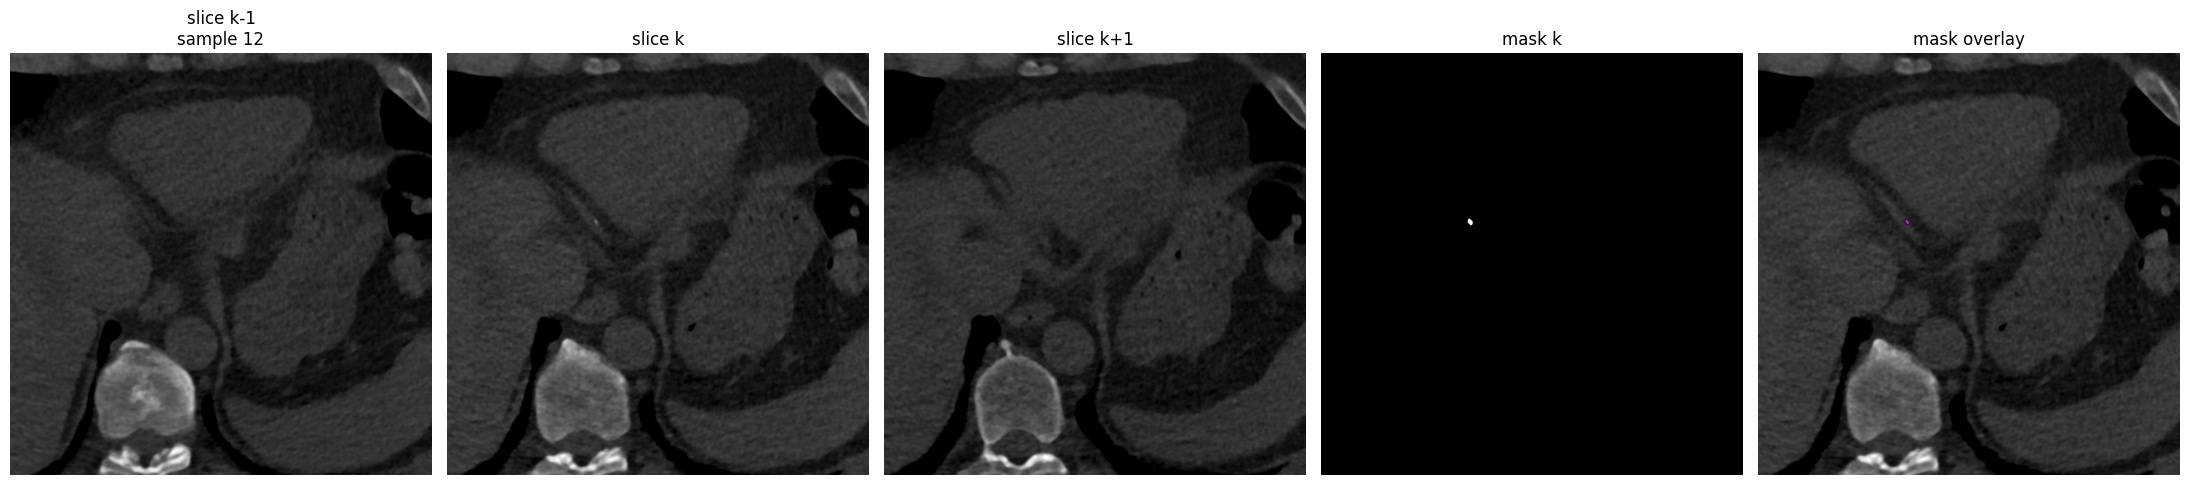

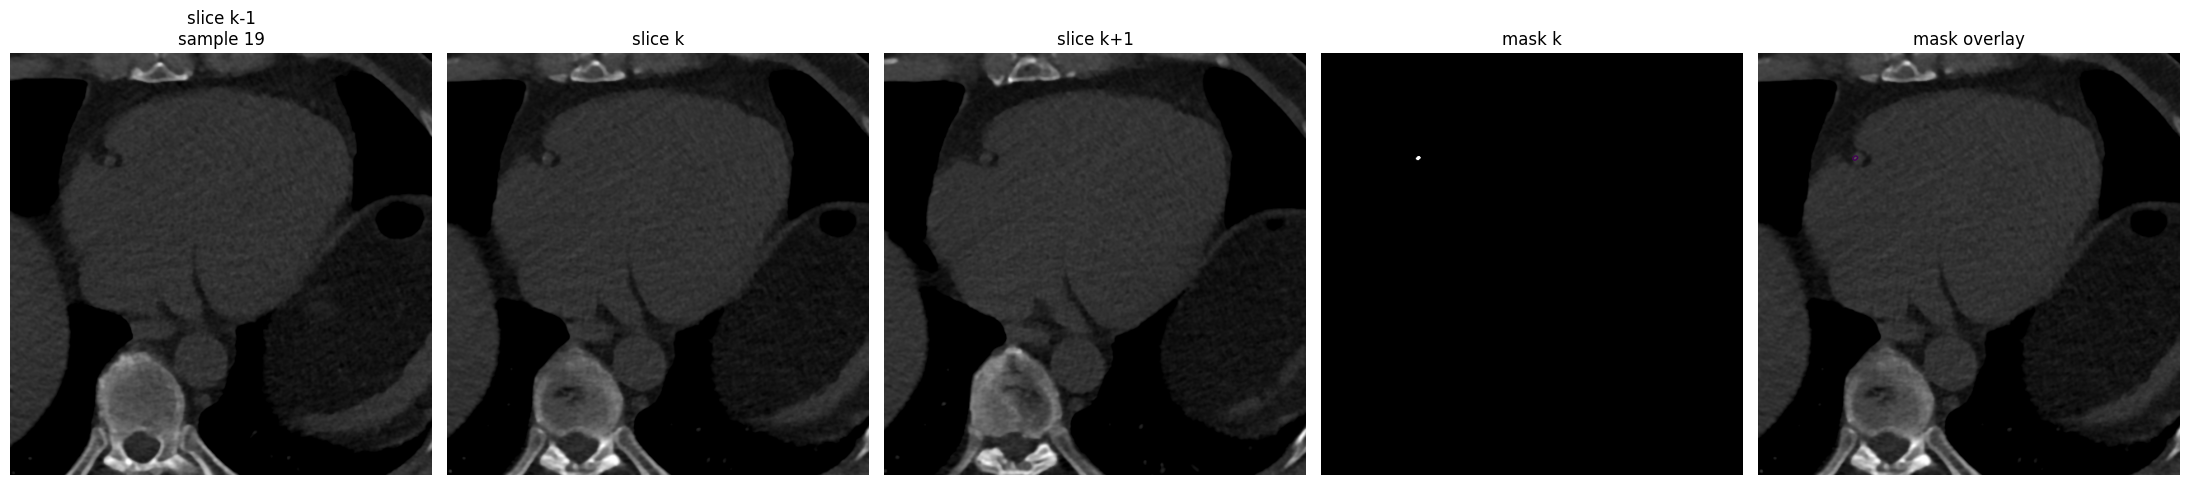

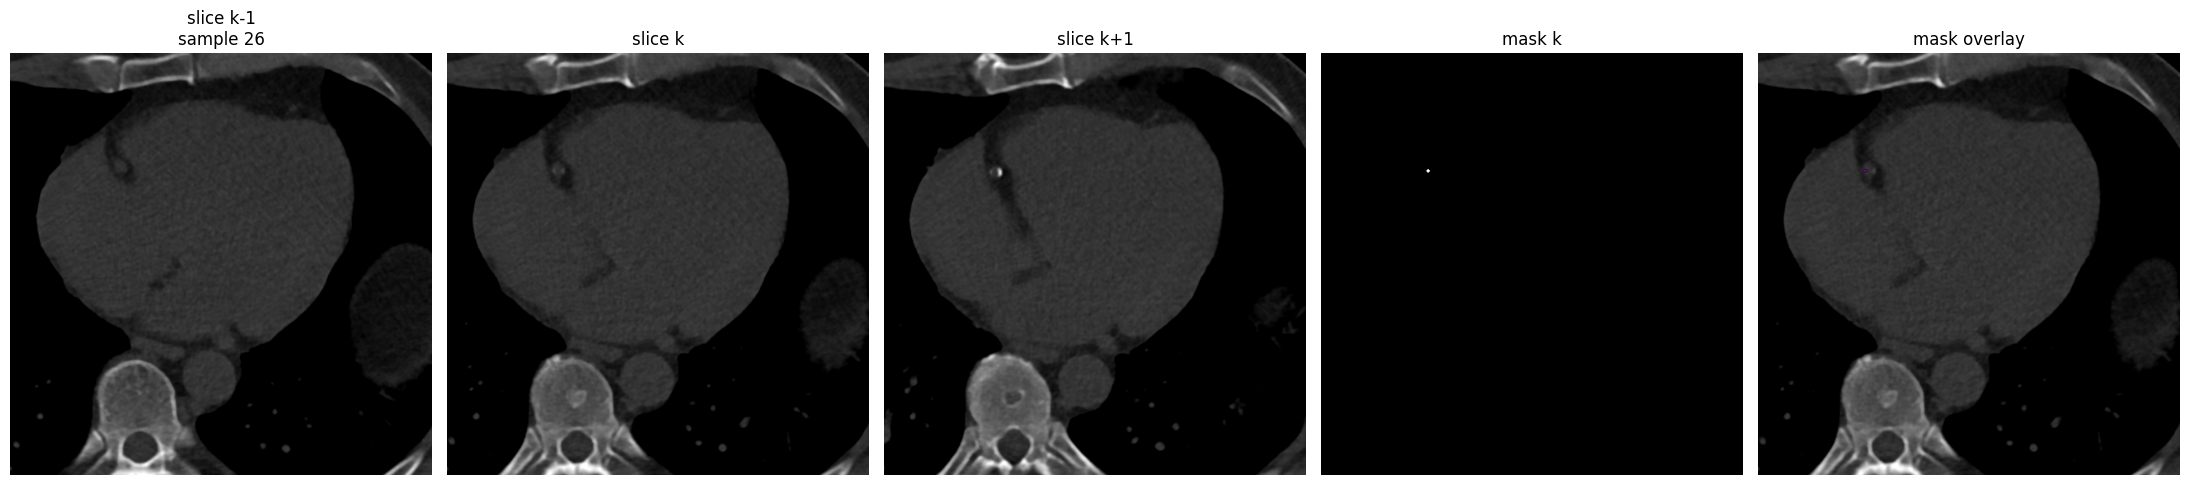

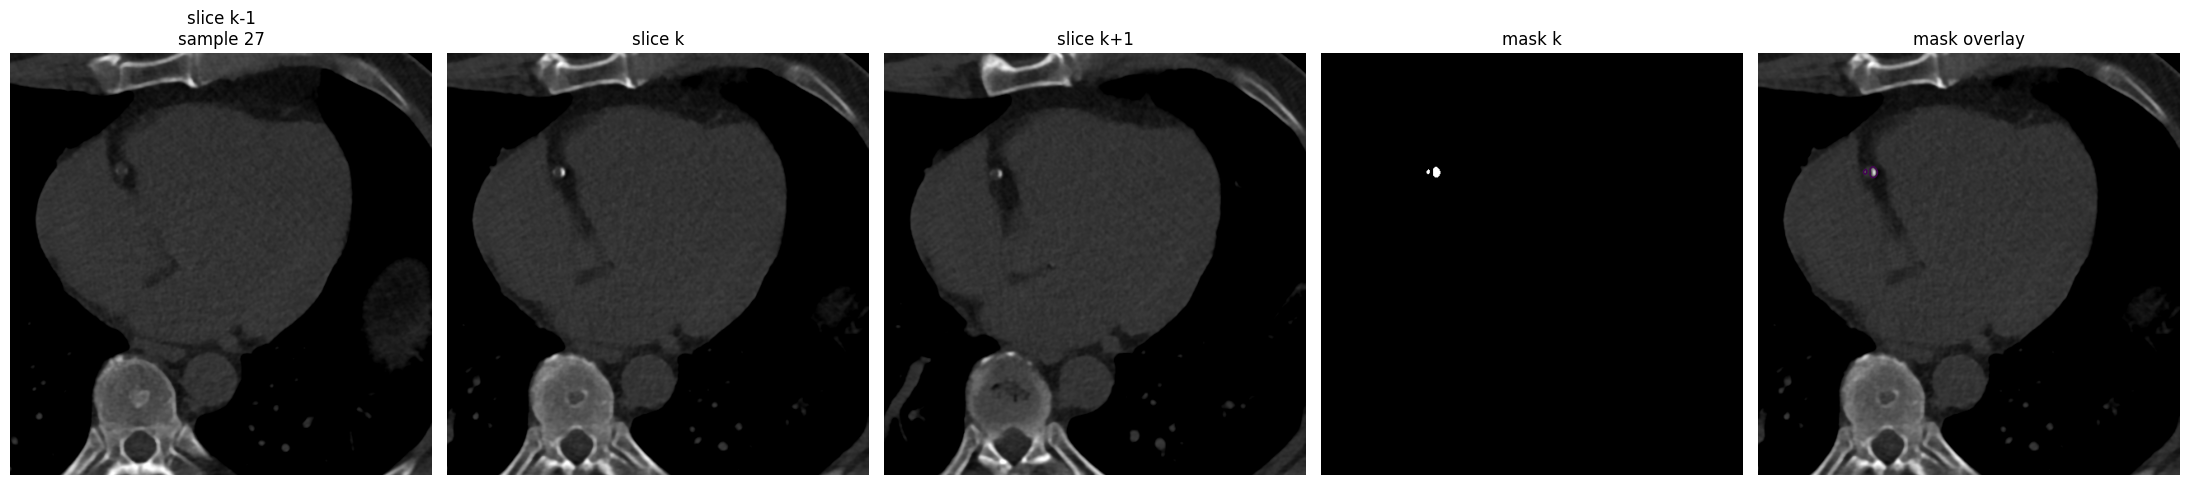

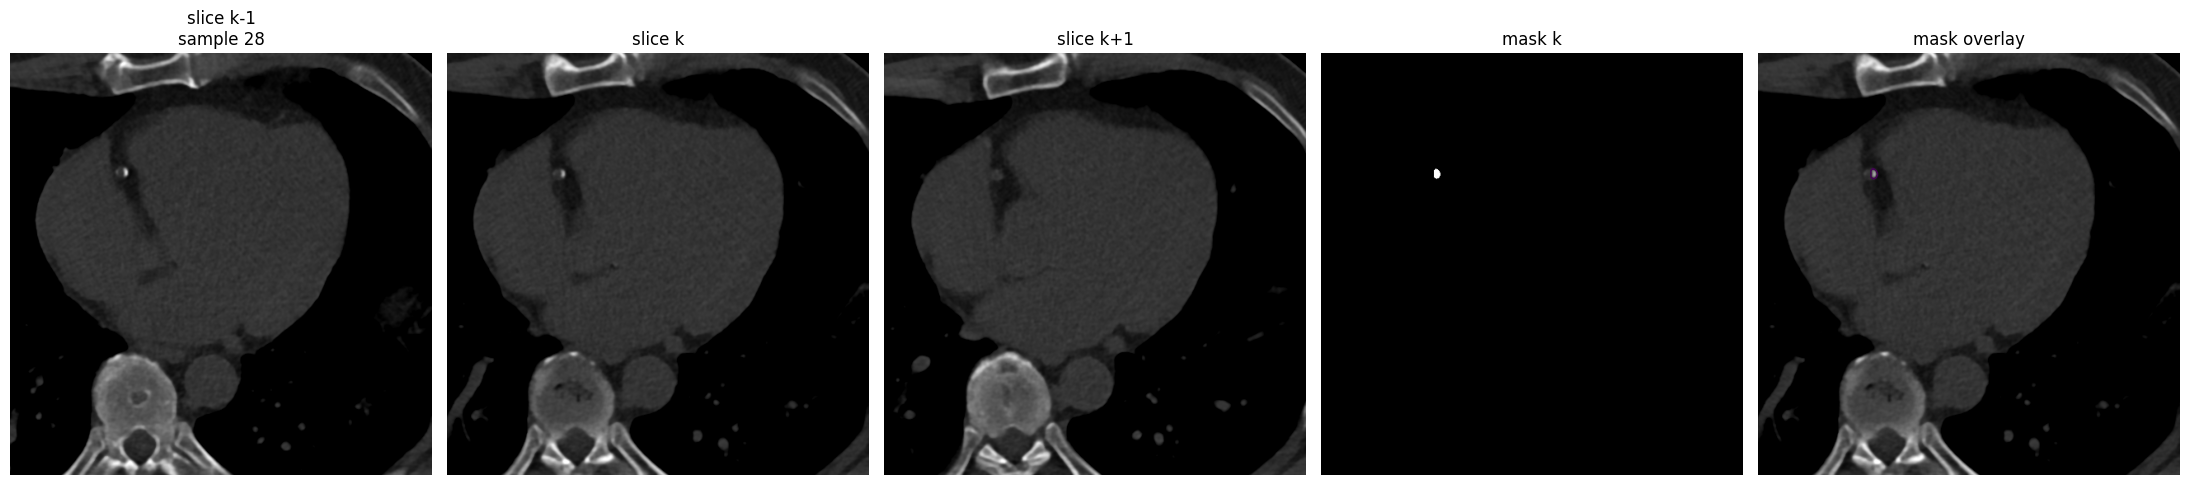

In [11]:
def positive_sample_indices(Y: np.ndarray) -> np.ndarray:
    return np.where(Y.reshape(Y.shape[0], -1).sum(axis=1) > 0)[0]

def visualize_case_samples(
    X: np.ndarray,
    Y: np.ndarray,
    max_samples: int = 5
) -> None:
    indices = positive_sample_indices(Y).tolist()[:max_samples]

    if not indices:
        print("No positive samples to visualize.")
        return

    for idx in indices:
        x = X[idx]
        y = Y[idx, 0]

        fig, axes = plt.subplots(1, 5, figsize=(22, 5))

        axes[0].imshow(x[0], cmap="gray")
        axes[0].set_title(f"slice k-1\nsample {idx}")
        axes[0].axis("off")

        axes[1].imshow(x[1], cmap="gray")
        axes[1].set_title("slice k")
        axes[1].axis("off")

        axes[2].imshow(x[2], cmap="gray")
        axes[2].set_title("slice k+1")
        axes[2].axis("off")

        axes[3].imshow(y, cmap="gray")
        axes[3].set_title("mask k")
        axes[3].axis("off")

        axes[4].imshow(x[1], cmap="gray")
        if y.max() > 0:
            axes[4].contour(y, levels=[0.5], linewidths=1)
        axes[4].set_title("mask overlay")
        axes[4].axis("off")

        plt.tight_layout()
        plt.show()

# Example:
visualize_case_samples(result_case_1["X"], result_case_1["Y"], max_samples=5)

In [12]:
def show_alignment_diagnostics(result: Dict[str, Any]) -> None:
    diag = result["index_diagnostics"]
    print("Decision:", diag.get("decision"))
    print("Chosen offset:", diag.get("chosen_offset"))
    print("Offset 0 median z-error:", diag.get("offset_0_median_abs_z_error"))
    print("Offset -1 median z-error:", diag.get("offset_minus1_median_abs_z_error"))

    pairs0 = diag.get("pairs_offset_0", pd.DataFrame())
    pairsm1 = diag.get("pairs_offset_minus1", pd.DataFrame())

    if not pairs0.empty:
        print("\nOffset 0 examples:")
        display(pairs0.head(10))

    if not pairsm1.empty:
        print("\nOffset -1 examples:")
        display(pairsm1.head(10))

# Example:
show_alignment_diagnostics(result_case_1)

Decision: auto_chose_zero_based
Chosen offset: 0
Offset 0 median z-error: 0.0
Offset -1 median z-error: 3.0

Offset 0 examples:


,xml_image_index,slice_index_used,xml_z,dicom_z,abs_z_error,offset
0,12,12,-214.75,-214.75,0.0,0
1,19,19,-193.75,-193.75,0.0,0
2,26,26,-172.75,-172.75,0.0,0
3,27,27,-169.75,-169.75,0.0,0
4,28,28,-166.75,-166.75,0.0,0
5,39,39,-133.75,-133.75,0.0,0
6,40,40,-130.75,-130.75,0.0,0
7,41,41,-127.75,-127.75,0.0,0



Offset -1 examples:


,xml_image_index,slice_index_used,xml_z,dicom_z,abs_z_error,offset
0,12,11,-214.75,-217.75,3.0,-1
1,19,18,-193.75,-196.75,3.0,-1
2,26,25,-172.75,-175.75,3.0,-1
3,27,26,-169.75,-172.75,3.0,-1
4,28,27,-166.75,-169.75,3.0,-1
5,39,38,-133.75,-136.75,3.0,-1
6,40,39,-130.75,-133.75,3.0,-1
7,41,40,-127.75,-130.75,3.0,-1


## 9. Batch process all XML-matched cases

In [13]:
def list_xml_matched_patient_ids(cfg: PreprocessConfig) -> List[str]:
    patient_ids = []
    for xml_path in ROOT_LABELS.glob("*.xml"):
        patient_id = xml_path.stem
        patient_dir = ROOT_SLICES / patient_id
        if patient_dir.exists() and patient_dir.is_dir():
            patient_ids.append(patient_id)

    patient_ids = sorted(patient_ids, key=numeric_sort_key)

    if cfg.max_cases is not None:
        patient_ids = patient_ids[:cfg.max_cases]

    return patient_ids

def process_all_matched_cases(cfg: PreprocessConfig) -> Tuple[pd.DataFrame, pd.DataFrame]:
    validate_paths(cfg)
    patient_ids = list_xml_matched_patient_ids(cfg)
    print("Matched patient/XML cases:", len(patient_ids))

    manifest_rows = []
    roi_audit_all = []

    for n, patient_id in enumerate(patient_ids, start=1):
        case_name = case_filename(patient_id)
        image_out = OUTPUT_IMGS / f"{case_name}_X.npy"
        mask_out = OUTPUT_MASKS / f"{case_name}_Y.npy"

        if (not cfg.overwrite_existing) and image_out.exists() and mask_out.exists():
            print(f"[{n}/{len(patient_ids)}] {patient_id}: skipped existing.")
            continue

        try:
            result = process_one_case(
                patient_id=patient_id,
                patient_dir=cfg.ROOT_SLICES / patient_id,
                xml_path=cfg.ROOT_LABELS / f"{patient_id}.xml",
                cfg=cfg,
                save_outputs=True
            )

            manifest_rows.append(result["summary"])

            audit = result["roi_audit"].copy()
            audit["patient_id"] = str(patient_id)
            audit["case_name"] = case_name
            roi_audit_all.append(audit)

            s = result["summary"]
            print(
                f"[{n}/{len(patient_ids)}] {patient_id}: "
                f"slices={s['num_dicom_slices']}, "
                f"positive_slices={s['num_positive_slices']}, "
                f"positive_pixels={s['num_positive_mask_pixels']}, "
                f"offset={s['chosen_index_offset']}"
            )

        except Exception as e:
            print(f"[{n}/{len(patient_ids)}] {patient_id}: ERROR -> {e}")
            manifest_rows.append({
                "patient_id": str(patient_id),
                "case_name": case_name,
                "status": "error",
                "error": str(e),
                "traceback": traceback.format_exc(limit=2),
            })

    manifest_df = pd.DataFrame(manifest_rows)
    roi_audit_df = pd.concat(roi_audit_all, ignore_index=True) if roi_audit_all else pd.DataFrame()

    manifest_path = OUTPUT_ROOT / "processing_manifest.csv"
    audit_path = OUTPUT_ROOT / "xml_roi_audit.csv"

    manifest_df.to_csv(manifest_path, index=False)
    roi_audit_df.to_csv(audit_path, index=False)

    print("Saved:", manifest_path)
    print("Saved:", audit_path)

    return manifest_df, roi_audit_df

# Run only after case 1 checks pass:
manifest_df, roi_audit_df = process_all_matched_cases(cfg)

Path validation passed.
Patient folders: 787
XML files: 451
Matched patient/XML cases: 449


c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.02563550858853922964.57849270.27551913059701870921967436326488'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '0.34146969484620434906.07222786.75056323906171411263200364792643'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '0.57309439704576738735.03631416.96857186245590364352369036904262'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#tab

[1/449] 0: slices=57, positive_slices=1, positive_pixels=31, offset=0


c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.77696772915220568699.88284712.07076227716920045346255373155906'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.07683691531181414205.80441060.36397870976295061911444693913746'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '0.62087141113535080786.02540426.31876620692679100480067193653313'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#tab

[2/449] 1: slices=57, positive_slices=8, positive_pixels=1115, offset=0


...

[447/449] 448: slices=46, positive_slices=13, positive_pixels=1915, offset=0


c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '6.49254047489662476384.90743834.06832111797707556444878121205443'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '1.85464441132452414663.85481983.00872619632037194814989770238354'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '4.02296149297574844631.83820341.35254460963817299715152149449600'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#tab

[448/449] 449: slices=53, positive_slices=9, positive_pixels=826, offset=0


c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '9.87189298291563457433.02057655.86977475791772479921020747890046'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '6.13451573821880766339.03907362.24817154807217039702460556381932'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\Quoc Thai\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '3.42108536816201233777.02268123.35610798185922400071569163093859'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#tab

[449/449] 450: slices=46, positive_slices=2, positive_pixels=79, offset=0
Saved: Gated_release_final\processed_data\processing_manifest.csv
Saved: Gated_release_final\processed_data\xml_roi_audit.csv


## 10. Audit the regenerated dataset

In [14]:
def summarize_manifest(manifest_df: pd.DataFrame) -> pd.DataFrame:
    if manifest_df.empty:
        print("Manifest is empty.")
        return pd.DataFrame()

    ok = manifest_df[manifest_df["status"] == "ok"].copy()
    if ok.empty:
        print("No successful cases.")
        return pd.DataFrame()

    return pd.DataFrame([{
        "successful_cases": len(ok),
        "total_dicom_slices": int(ok["num_dicom_slices"].sum()),
        "total_positive_slices": int(ok["num_positive_slices"].sum()),
        "total_positive_mask_pixels": int(ok["num_positive_mask_pixels"].sum()),
        "cases_with_zero_positive_pixels": int((ok["num_positive_mask_pixels"] == 0).sum()),
    }])

# Example:
summarize_manifest(manifest_df)

,successful_cases,total_dicom_slices,total_positive_slices,total_positive_mask_pixels,cases_with_zero_positive_pixels
0,449,22992,3658,533131,1


## 11. Optional: generate a new case-level train/val/test split

After regenerating the corrected `.npy` files, you may create a fresh case split.

In [15]:
def generate_case_splits(
    output_root: Path,
    train_frac: float = 0.70,
    val_frac: float = 0.15,
    test_frac: float = 0.15,
    seed: int = 30
) -> pd.DataFrame:
    from sklearn.model_selection import train_test_split

    assert math.isclose(train_frac + val_frac + test_frac, 1.0, rel_tol=1e-6)

    images_dir = output_root / "images"
    case_ids = sorted([p.stem for p in images_dir.glob("*.npy")])
    assert case_ids, "No processed cases found."

    train_cases, temp_cases = train_test_split(
        case_ids,
        test_size=(1 - train_frac),
        random_state=seed,
        shuffle=True
    )

    relative_test_frac = test_frac / (val_frac + test_frac)
    val_cases, test_cases = train_test_split(
        temp_cases,
        test_size=relative_test_frac,
        random_state=seed,
        shuffle=True
    )

    rows = []
    rows += [{"case_id": c, "split": "train"} for c in train_cases]
    rows += [{"case_id": c, "split": "val"} for c in val_cases]
    rows += [{"case_id": c, "split": "test"} for c in test_cases]

    splits_df = pd.DataFrame(rows).sort_values(["split", "case_id"]).reset_index(drop=True)
    path = output_root / "case_splits.csv"
    splits_df.to_csv(path, index=False)

    print("Saved:", path)
    print(splits_df["split"].value_counts())
    return splits_df

# Example:
case_splits_df = generate_case_splits(cfg.OUTPUT_ROOT)

Saved: Gated_release_final\processed_data\case_splits.csv
split
train    314
test      68
val       67
Name: count, dtype: int64


# Final checklist

Proceed only when all are true:

- `1.xml` produces nonzero positive mask pixels.
- Mask overlays land on the actual CAC regions.
- Index diagnostics show the lower-error offset clearly.
- `.npy` output shapes are:
  ```text
  images/xxx_X.npy -> (D, 3, 512, 512)
  masks/xxx_Y.npy  -> (D, 1, 512, 512)
  ```
- The regenerated dataset manifest looks sane.